In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\parth\OneDrive\Desktop\german-energy-forecast\DATA\data\final_dataset.csv")

df["time"] = pd.to_datetime(df["time"])

df.head()

,time,load,wind,solar,price
0,2025-01-01 00:00:00,47741.75,35377.75,9.50,2.16
1,2025-01-01 01:00:00,46867.25,35915.50,9.50,1.60
2,2025-01-01 02:00:00,45797.50,36381.00,9.00,0.00
3,2025-01-01 03:00:00,44623.50,34560.50,9.25,-0.01
4,2025-01-01 04:00:00,43626.00,34441.50,9.00,-0.01


In [5]:
df.corr(numeric_only=True)

,load,wind,solar,price
load,1.000000,0.158507,0.095103,0.378086
wind,0.158507,1.000000,-0.271380,-0.278662
solar,0.095103,-0.271380,1.000000,-0.542810
price,0.378086,-0.278662,-0.542810,1.000000


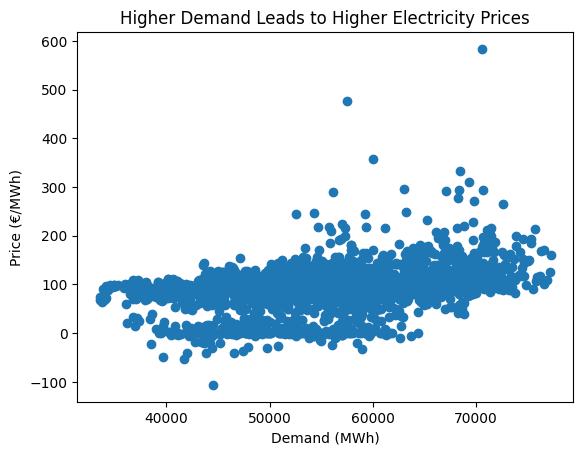

In [10]:
df_sample = df.sample(2000)

plt.figure()
plt.scatter(df_sample["load"], df_sample["price"])
plt.xlabel("Demand (MWh)")
plt.ylabel("Price (€/MWh)")
plt.title("Higher Demand Leads to Higher Electricity Prices")
plt.show()

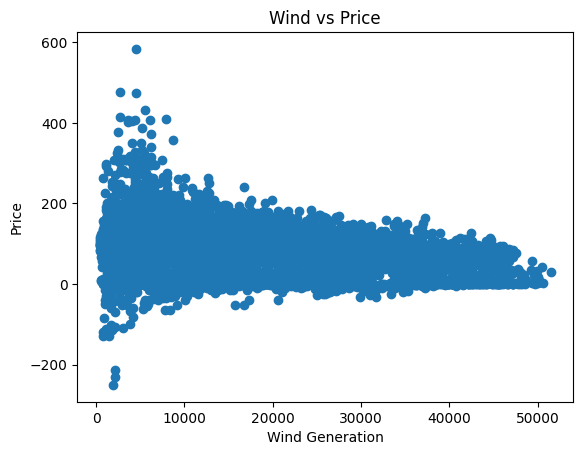

In [7]:
plt.figure()
plt.scatter(df["wind"], df["price"])
plt.xlabel("Wind Generation")
plt.ylabel("Price")
plt.title("Wind vs Price")
plt.show()

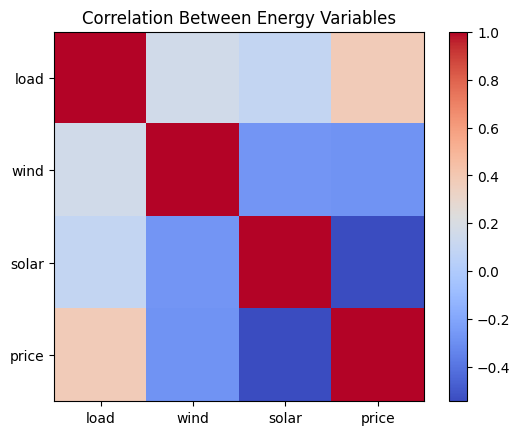

In [11]:
plt.figure()
plt.imshow(df.corr(numeric_only=True), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(4), ["load","wind","solar","price"])
plt.yticks(range(4), ["load","wind","solar","price"])
plt.title("Correlation Between Energy Variables")
plt.show()

In [ ]:
### Key Insights

- Electricity prices increase with demand
- Wind and solar generation reduce electricity prices
- Negative prices occur during high renewable production periods

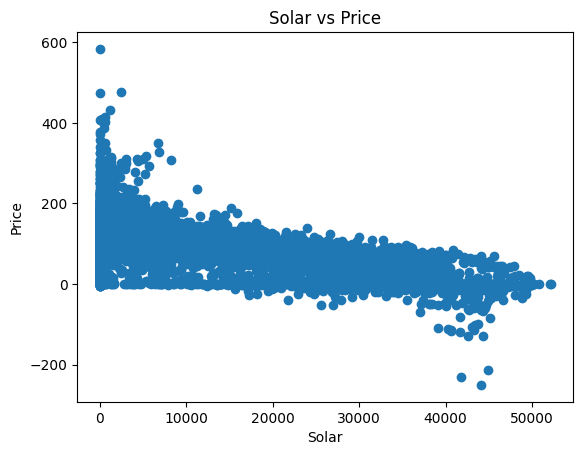

In [8]:
plt.figure()
plt.scatter(df["solar"], df["price"])
plt.xlabel("Solar")
plt.ylabel("Price")
plt.title("Solar vs Price")
plt.show()

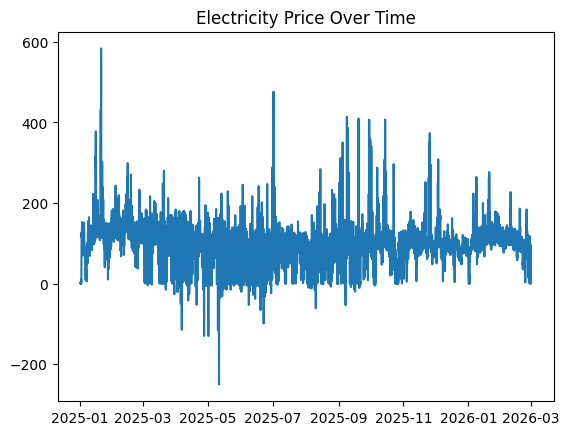

In [9]:
plt.figure()
plt.plot(df["time"], df["price"])
plt.title("Electricity Price Over Time")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[["load", "wind", "solar"]]

# Target
y = df["price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

print("Model trained successfully 🚀")

Model trained successfully 🚀


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 16.284703233246294
R2 Score: 0.7892038698585583


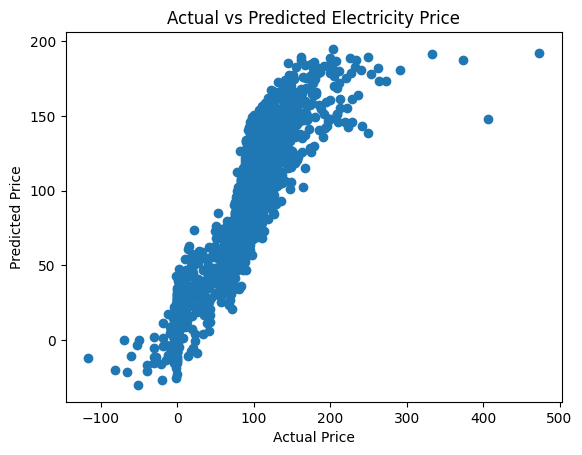

In [16]:
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Electricity Price")
plt.show()

In [17]:
coefficients = pd.DataFrame({
    "Feature": ["load", "wind", "solar"],
    "Impact": model.coef_
})

coefficients

,Feature,Impact
0,load,0.002843
1,wind,-0.002639
2,solar,-0.003155


In [18]:
df["renewable_ratio"] = (df["wind"] + df["solar"]) / df["load"]

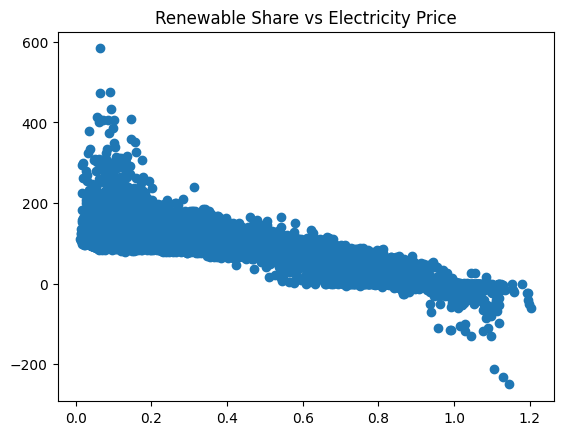

In [19]:
plt.scatter(df["renewable_ratio"], df["price"])
plt.title("Renewable Share vs Electricity Price")
plt.show()

In [20]:
df["price_spike"] = df["price"] > df["price"].quantile(0.9)

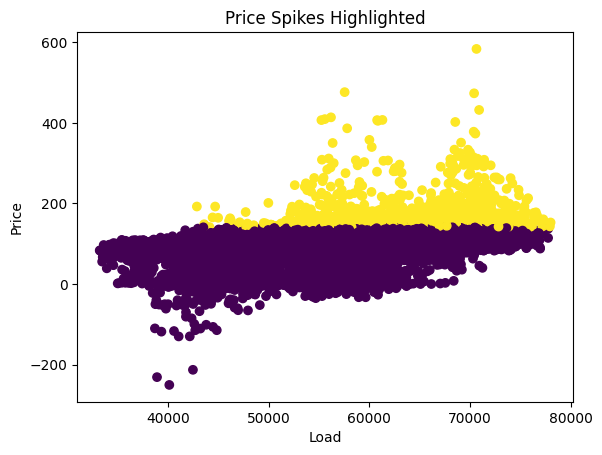

In [21]:
plt.figure()
plt.scatter(df["load"], df["price"], c=df["price_spike"])
plt.title("Price Spikes Highlighted")
plt.xlabel("Load")
plt.ylabel("Price")
plt.show()

In [22]:
spike_rate = df["price_spike"].mean()
print("Percentage of high-risk price spikes:", spike_rate * 100, "%")

Percentage of high-risk price spikes: 10.007857002553527 %


In [23]:
df["renewable_ratio"] = (df["wind"] + df["solar"]) / df["load"]

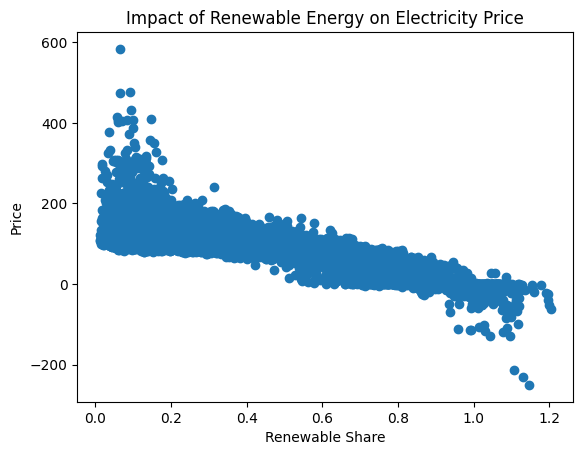

In [24]:
plt.figure()
plt.scatter(df["renewable_ratio"], df["price"])
plt.xlabel("Renewable Share")
plt.ylabel("Price")
plt.title("Impact of Renewable Energy on Electricity Price")
plt.show()

In [25]:
df["residual_load"] = df["load"] - (df["wind"] + df["solar"])

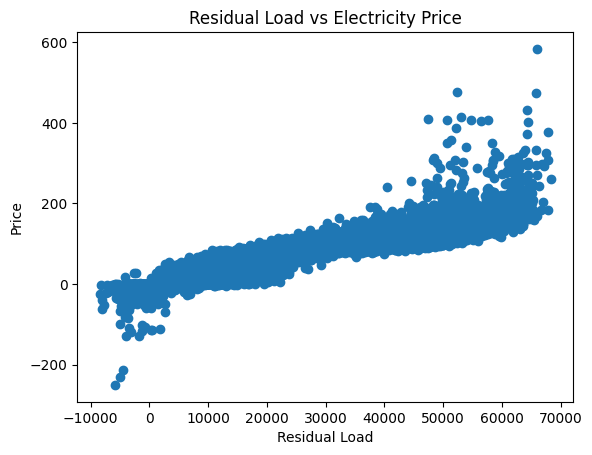

In [26]:
plt.figure()
plt.scatter(df["residual_load"], df["price"])
plt.xlabel("Residual Load")
plt.ylabel("Price")
plt.title("Residual Load vs Electricity Price")
plt.show()